=== أعلى 5 توصيات للأشخاص الذين شاهدوا فيلم (Moana) ===
🎬 الفيلم المحدد في البيانات: Moana



,البرنامج/الفيلم الموصى به,درجة التشابه (Similarity Score)
0,Trolls,0.572358
1,Surf's Up : WaveMania,0.529424
2,The Mermaid Princess,0.493362
3,The Boss Baby,0.448557
4,The Jetsons & WWE: Robo-WrestleMania!,0.438942


C:\Users\96656\AppData\Local\Temp\ipykernel_15792\3998165733.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


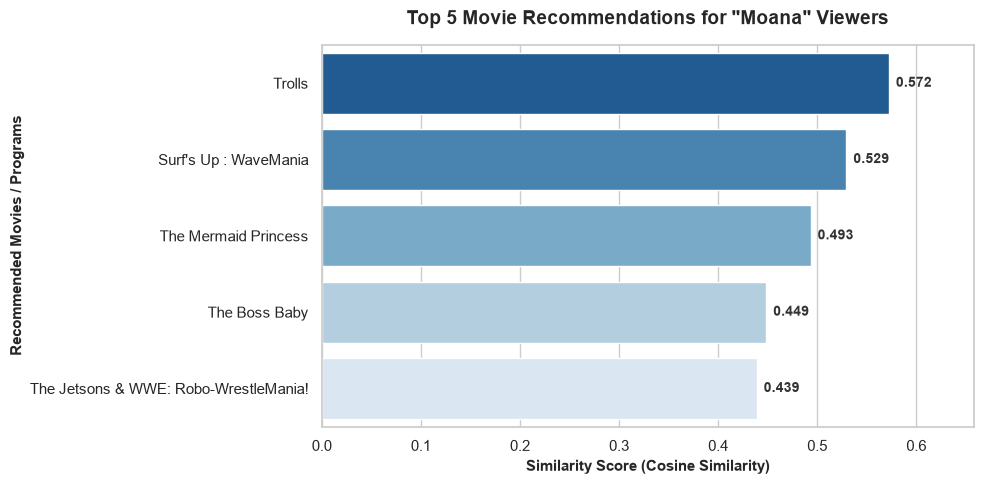


=== عينة من التوصيات المخصصة للمستخدمين (User Sample) ===

👤 المستخدم رقم: 1
🍿 شاهد سابقاً: Baywatch
💡 المقترحات الموصى بها له:
🎬 الفيلم المحدد في البيانات: Baywatch



,البرنامج/الفيلم الموصى به
0,Inside
1,Alien: Covenant
2,The Hunter's Prayer



👤 المستخدم رقم: 5
🍿 شاهد سابقاً: 24     :00 AM - :00 AM
💡 المقترحات الموصى بها له:
🎬 الفيلم المحدد في البيانات: 24     :00 AM - :00 AM



,البرنامج/الفيلم الموصى به
0,24 :00 AM - :00 PM
1,24 :00 PM - :00 AM
2,24 :00 PM - :00 PM



👤 المستخدم رقم: 9
🍿 شاهد سابقاً: Along Came Polly
💡 المقترحات الموصى بها له:
🎬 الفيلم المحدد في البيانات: Along Came Polly



,البرنامج/الفيلم الموصى به
0,Billy Elliot the Musical Live
1,21 Grams
2,Svengali


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

file_path = 'stc TV Data Set_T3.xlsx'
df = pd.read_excel(file_path)

user_col = 'user_id_maped'
title_col = 'program_name'
rating_col = 'rating'

user_movie_data = df.groupby([user_col, title_col])[rating_col].mean().reset_index()

user_item_matrix = user_movie_data.pivot_table(
    index=user_col,
    columns=title_col,
    values=rating_col
).fillna(0)

item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

def get_top_recommendations(movie_name, top_n=5):
    matched_titles = [col for col in item_similarity_df.columns if movie_name.lower() in str(col).lower()]

    if not matched_titles:
        print(f"❌ لم يتم العثور على الفيلم '{movie_name}' في قاعدة البيانات.")
        return None

    actual_title = matched_titles[0]
    print(f"🎬 الفيلم المحدد في البيانات: {actual_title}\n")

    similar_scores = item_similarity_df[actual_title].sort_values(ascending=False)
    similar_scores = similar_scores.drop(actual_title)

    top_recommendations = similar_scores.head(top_n).reset_index()
    top_recommendations.columns = ['البرنامج/الفيلم الموصى به', 'درجة التشابه (Similarity Score)']
    return top_recommendations

print("=========================================================")
print("=== أعلى 5 توصيات للأشخاص الذين شاهدوا فيلم (Moana) ===")
print("=========================================================")

moana_recs = get_top_recommendations('Moana', top_n=5)

if moana_recs is not None:
    display(moana_recs)

    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(
        data=moana_recs,
        x='درجة التشابه (Similarity Score)',
        y='البرنامج/الفيلم الموصى به',
        palette='Blues_r'
    )

    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f'{width:.3f}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=10, fontweight='bold', color='#333333'
        )

    plt.title('Top 5 Movie Recommendations for "Moana" Viewers', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Similarity Score (Cosine Similarity)', fontsize=11, fontweight='bold')
    plt.ylabel('Recommended Movies / Programs', fontsize=11, fontweight='bold')
    plt.xlim(0, max(moana_recs['درجة التشابه (Similarity Score)']) * 1.15)

    plt.tight_layout()
    plt.show()

print("\n=========================================================")
print("=== عينة من التوصيات المخصصة للمستخدمين (User Sample) ===")
print("=========================================================")

sample_users = user_item_matrix.index[:3]

for user in sample_users:
    watched_programs = user_item_matrix.loc[user][user_item_matrix.loc[user] > 0].index.tolist()

    if watched_programs:
        fav_program = watched_programs[0]
        print(f"\n👤 المستخدم رقم: {user}")
        print(f"🍿 شاهد سابقاً: {fav_program}")
        print("💡 المقترحات الموصى بها له:")
        recs = get_top_recommendations(fav_program, top_n=3)
        if recs is not None:
            display(recs[['البرنامج/الفيلم الموصى به']])